# Project 3 — Unsupervised Learning: Customer Segmentation
**DecodeLabs Batch 2026**

**Goal:** Use distance-based algorithms (K-Means) to discover hidden mathematical groupings in unlabeled retail/customer data.

**Pipeline (IPO Architecture):**
1. **Scale** — Standardize features (input)
2. **Compress** — PCA dimensionality reduction (process)
3. **Cluster** — K-Means, validated with Elbow Method + Silhouette Score (process)
4. **Translate** — Reverse-engineer centroids into human-readable business personas (output)

**Dataset:** Mall Customer Segmentation Dataset (Kaggle) — `Mall_Customers.csv`
Columns: `CustomerID, Gender, Age, Annual Income (k$), Spending Score (1-100)`

> If you're using a different dataset, just update the `DATA_PATH` / column names in the **Load Data** section — the rest of the pipeline is written generically and will adapt to however many numeric features you feed it.


## 1. Setup & Imports

In [15]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Dimensionality reduction
from sklearn.decomposition import PCA

# Clustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

# Misc
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 2. Load Data

In [27]:
DATA_PATH = "Mall_Customers.csv" 

df = pd.read_csv(DATA_PATH)
df.head()
df


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


## 3. Exploratory Data Analysis (EDA)

In [4]:
df.info()
print("\nMissing values per column:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
df.describe(include="all").T


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB

Missing values per column:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Duplicate rows: 0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CustomerID,200.0,NaN,NaN,NaN,100.5,57.879185,1.0,50.75,100.5,150.25,200.0
Gender,200,2,Female,112,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,200.0,NaN,NaN,NaN,38.85,13.969007,18.0,28.75,36.0,49.0,70.0
Annual Income (k$),200.0,NaN,NaN,NaN,60.56,26.264721,15.0,41.5,61.5,78.0,137.0
Spending Score (1-100),200.0,NaN,NaN,NaN,50.2,25.823522,1.0,34.75,50.0,73.0,99.0


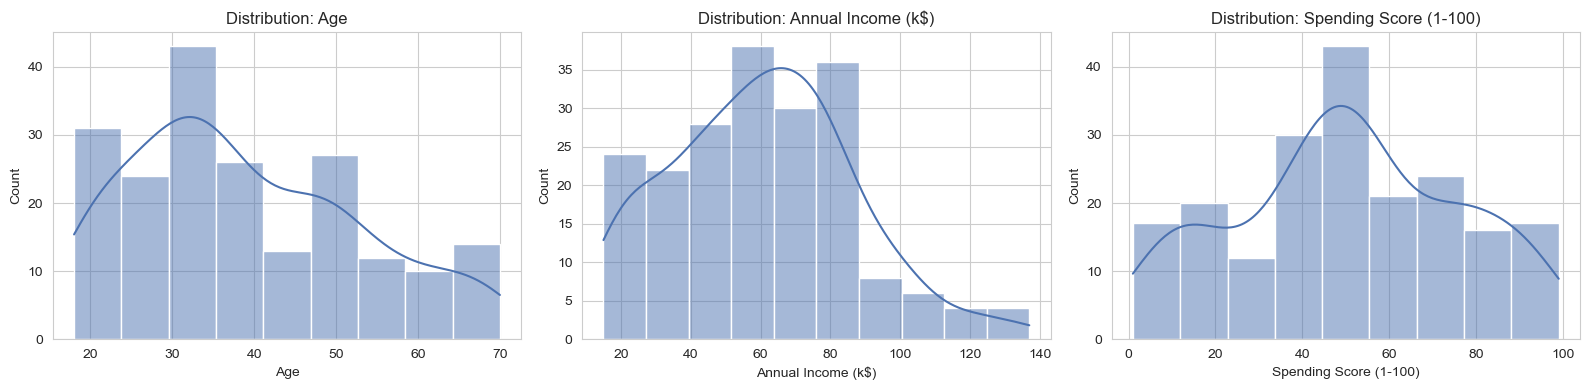

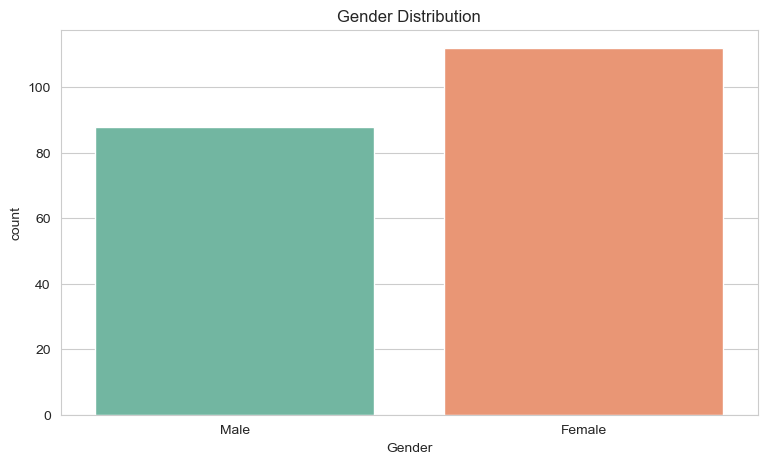

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ["Age", "Annual Income (k$)", "Spending Score (1-100)"]):
    sns.histplot(df[col], kde=True, ax=ax, color="#4C72B0")
    ax.set_title(f"Distribution: {col}")
plt.tight_layout()
plt.show()

if "Gender" in df.columns:
    sns.countplot(x="Gender", data=df, palette="Set2")
    plt.title("Gender Distribution")
    plt.show()


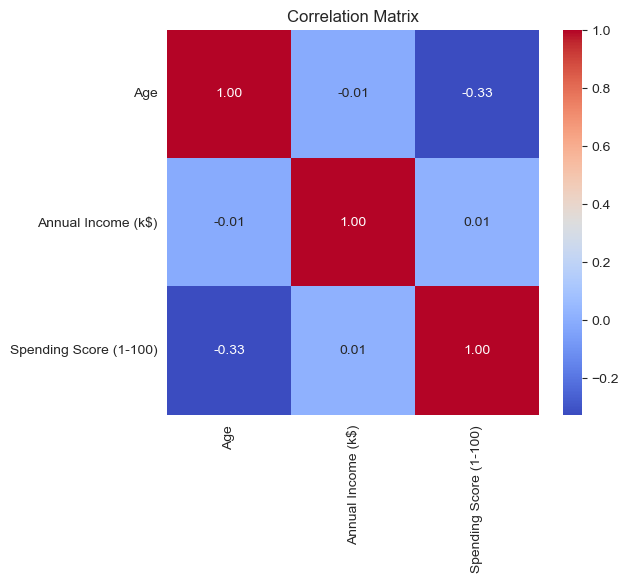

In [6]:
# Correlation heatmap of numeric features
numeric_df = df.select_dtypes(include=[np.number]).drop(columns=["CustomerID"], errors="ignore")
plt.figure(figsize=(6, 5))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()


## 4. Feature Engineering & Selection

We drop identifier columns (`CustomerID`), encode categorical variables, and select the features that will feed the clustering pipeline.


In [7]:
feature_df = df.copy()

# Drop non-informative identifier column
feature_df = feature_df.drop(columns=["CustomerID"], errors="ignore")

# Encode Gender (categorical -> numeric) if present
if "Gender" in feature_df.columns:
    le = LabelEncoder()
    feature_df["Gender"] = le.fit_transform(feature_df["Gender"])  # Male/Female -> 0/1

feature_df.head()


,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


## 5. Phase 1 — SCALE: Standardization

Distance-based algorithms (K-Means, PCA) are sensitive to feature magnitude. An income axis in the tens of thousands would swallow a 1–100 spending score axis unless every feature is put on the same footing.

`z = (x - μ) / σ`


In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(feature_df)

X_scaled_df = pd.DataFrame(X_scaled, columns=feature_df.columns)
X_scaled_df.describe().T[["mean", "std"]]


,mean,std
Gender,3.108624e-17,1.002509
Age,-1.021405e-16,1.002509
Annual Income (k$),-2.131628e-16,1.002509
Spending Score (1-100),-1.465494e-16,1.002509


## 6. Phase 2 — COMPRESS: PCA (Dimensionality Reduction)

We apply PCA and keep enough components to retain **95% of cumulative explained variance** (the enterprise-standard threshold). With only a handful of features (as in the Mall Customers dataset) this may just mean keeping 2–3 components for visualization; with 20+ engineered features, PCA becomes essential rather than optional.


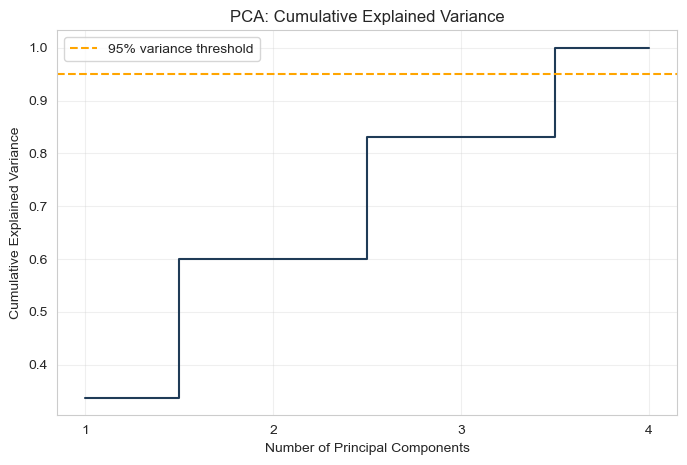

PC1: explained variance = 0.337, cumulative = 0.337
PC2: explained variance = 0.262, cumulative = 0.599
PC3: explained variance = 0.233, cumulative = 0.832
PC4: explained variance = 0.168, cumulative = 1.000


In [9]:
# Fit PCA with all components first to inspect the variance curve
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_scaled)

explained_var = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

plt.figure(figsize=(8, 5))
plt.step(range(1, len(cumulative_var) + 1), cumulative_var, where="mid", color="#1f3b57")
plt.axhline(y=0.95, color="orange", linestyle="--", label="95% variance threshold")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA: Cumulative Explained Variance")
plt.xticks(range(1, len(cumulative_var) + 1))
plt.legend()
plt.grid(alpha=0.3)
plt.show()

for i, (ev, cv) in enumerate(zip(explained_var, cumulative_var), start=1):
    print(f"PC{i}: explained variance = {ev:.3f}, cumulative = {cv:.3f}")


In [10]:
# Choose the smallest number of components that reach the 95% threshold
# (For low-dimensional datasets like Mall Customers, we also cap at 3 for easy visualization)
n_components_95 = np.argmax(cumulative_var >= 0.95) + 1
N_COMPONENTS = min(n_components_95, 3) if X_scaled.shape[1] <= 5 else n_components_95

print(f"Components needed for 95% variance: {n_components_95}")
print(f"Using N_COMPONENTS = {N_COMPONENTS} for clustering/visualization")

pca = PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

pca_cols = [f"PC{i+1}" for i in range(N_COMPONENTS)]
X_pca_df = pd.DataFrame(X_pca, columns=pca_cols)
X_pca_df.head()


Components needed for 95% variance: 4
Using N_COMPONENTS = 3 for clustering/visualization


,PC1,PC2,PC3
0,-0.406383,-0.520714,2.072527
1,-1.427673,-0.367310,2.277644
2,0.050761,-1.894068,0.367375
3,-1.694513,-1.631908,0.717467
4,-0.313108,-1.810483,0.426460


## 7. Phase 3 — CLUSTER: Finding Optimal K

K-Means cannot determine how many clusters exist on its own — we must mathematically prove the right K using two diagnostic gatekeepers:

- **Elbow Method** — plots Within-Cluster Sum of Squares (WCSS) vs. K; the "elbow" marks diminishing returns.
- **Silhouette Score** — measures cohesion vs. separation; closer to +1 is better.


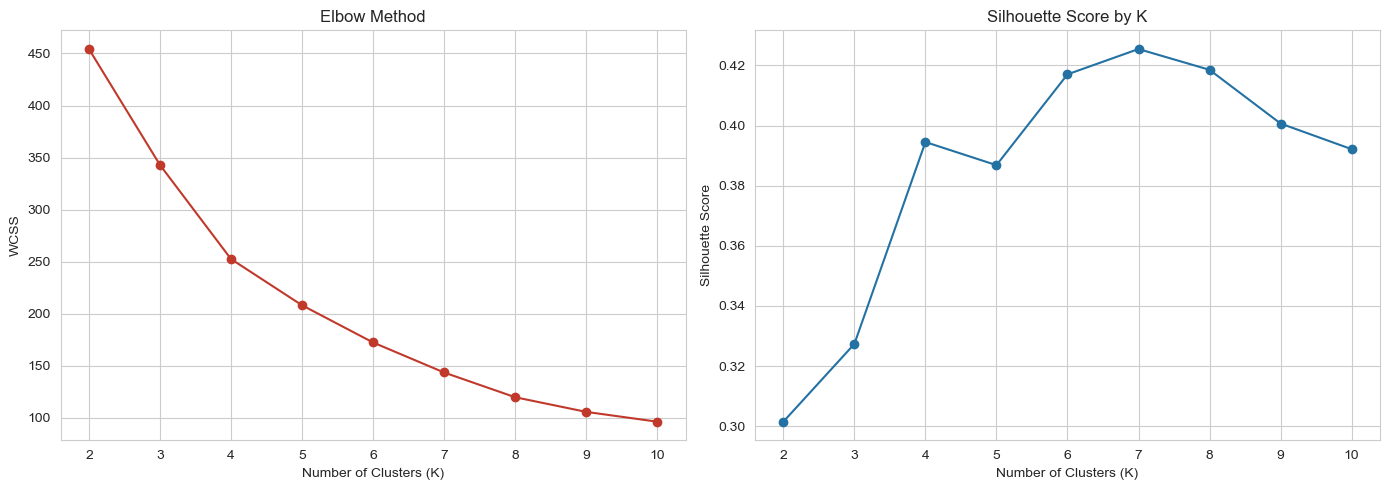

K=2: WCSS=454.3, Silhouette=0.301
K=3: WCSS=342.9, Silhouette=0.327
K=4: WCSS=252.6, Silhouette=0.395
K=5: WCSS=208.2, Silhouette=0.387
K=6: WCSS=172.5, Silhouette=0.417
K=7: WCSS=143.6, Silhouette=0.425
K=8: WCSS=119.9, Silhouette=0.419
K=9: WCSS=105.8, Silhouette=0.401
K=10: WCSS=96.4, Silhouette=0.392


In [16]:
K_RANGE = range(2, 11)
wcss = []
silhouette_scores = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_pca)
    wcss.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_pca, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(K_RANGE), wcss, marker="o", color="#c0392b")
axes[0].set_xlabel("Number of Clusters (K)")
axes[0].set_ylabel("WCSS")
axes[0].set_title("Elbow Method")

axes[1].plot(list(K_RANGE), silhouette_scores, marker="o", color="#2471a3")
axes[1].set_xlabel("Number of Clusters (K)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score by K")

plt.tight_layout()
plt.show()

for k, w, s in zip(K_RANGE, wcss, silhouette_scores):
    print(f"K={k}: WCSS={w:.1f}, Silhouette={s:.3f}")


In [17]:
# Optimal K = the K with the highest silhouette score (mathematically justified pick)
optimal_k = list(K_RANGE)[int(np.argmax(silhouette_scores))]
print(f"Optimal K (by Silhouette Score): {optimal_k}")

# You can override this manually after inspecting the elbow plot, e.g.:
# optimal_k = 4


Optimal K (by Silhouette Score): 7


## 8. Final K-Means Model

In [18]:
kmeans = KMeans(n_clusters=optimal_k, init="k-means++", n_init=10, random_state=RANDOM_STATE)
cluster_labels = kmeans.fit_predict(X_pca)

df["Cluster"] = cluster_labels
final_silhouette = silhouette_score(X_pca, cluster_labels)
print(f"Final model: K={optimal_k}, Silhouette Score={final_silhouette:.3f}")

df.head()


Final model: K=7, Silhouette Score=0.425


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,5
1,2,Male,21,15,81,5
2,3,Female,20,16,6,0
3,4,Female,23,16,77,6
4,5,Female,31,17,40,6


## 9. Visualizing the Clusters in PCA Space

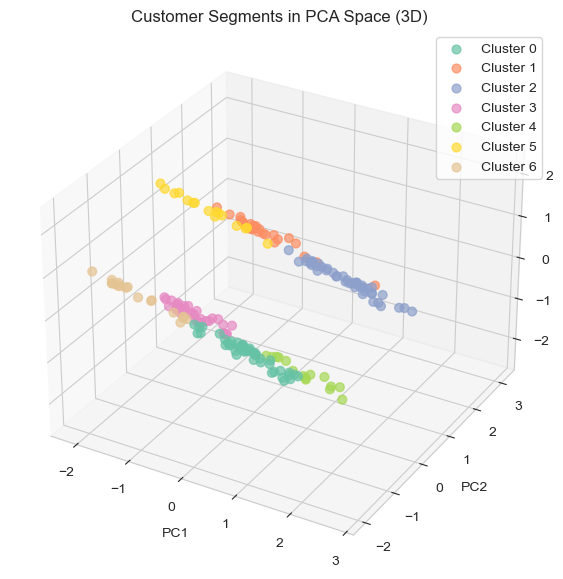

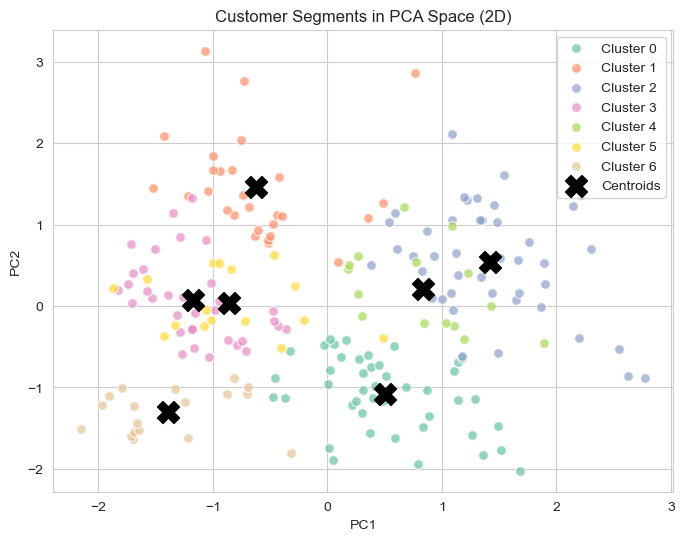

In [19]:
palette = sns.color_palette("Set2", n_colors=optimal_k)

if N_COMPONENTS >= 3:
    fig = plt.figure(figsize=(9, 7))
    ax = fig.add_subplot(111, projection="3d")
    for c in range(optimal_k):
        mask = cluster_labels == c
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1], X_pca[mask, 2],
                   label=f"Cluster {c}", color=palette[c], s=40, alpha=0.7)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_zlabel("PC3")
    ax.set_title("Customer Segments in PCA Space (3D)")
    ax.legend()
    plt.show()

# Always also show the 2D view (PC1 vs PC2) for clarity
plt.figure(figsize=(8, 6))
for c in range(optimal_k):
    mask = cluster_labels == c
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=f"Cluster {c}",
                color=palette[c], s=50, alpha=0.7, edgecolor="white")

centers_2d = kmeans.cluster_centers_[:, :2]
plt.scatter(centers_2d[:, 0], centers_2d[:, 1], marker="X", s=250,
            c="black", label="Centroids")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Customer Segments in PCA Space (2D)")
plt.legend()
plt.show()


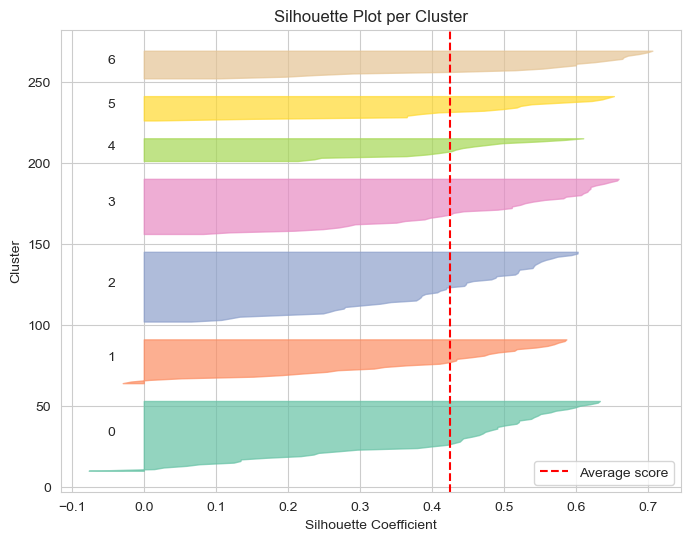

In [20]:
# Silhouette plot per sample (diagnostic detail)
sample_silhouette_values = silhouette_samples(X_pca, cluster_labels)

fig, ax = plt.subplots(figsize=(8, 6))
y_lower = 10
for c in range(optimal_k):
    cluster_silhouette_vals = sample_silhouette_values[cluster_labels == c]
    cluster_silhouette_vals.sort()
    size_cluster = cluster_silhouette_vals.shape[0]
    y_upper = y_lower + size_cluster
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_silhouette_vals,
                      facecolor=palette[c], edgecolor=palette[c], alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size_cluster, str(c))
    y_lower = y_upper + 10

ax.axvline(x=final_silhouette, color="red", linestyle="--", label="Average score")
ax.set_xlabel("Silhouette Coefficient")
ax.set_ylabel("Cluster")
ax.set_title("Silhouette Plot per Cluster")
ax.legend()
plt.show()


## 10. Phase 4 — TRANSLATE: Reverse-Engineering Centroids

K-Means was fit in PCA space, so its centroid coordinates are abstract and meaningless to a business stakeholder. We map them back through the **inverse PCA transform** and then the **inverse StandardScaler transform** to recover interpretable, human-centric values (e.g. actual Age, actual Income in $).

`C_original = (C_scaled ⊙ σ) + μ`


In [21]:
# Inverse-transform cluster centroids: PCA space -> scaled feature space -> original units
centroids_scaled = pca.inverse_transform(kmeans.cluster_centers_)
centroids_original = scaler.inverse_transform(centroids_scaled)

centroids_df = pd.DataFrame(centroids_original, columns=feature_df.columns)
centroids_df.index.name = "Cluster"
centroids_df.round(1)


,Gender,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,
0,0.0,46.0,46.3,36.8
1,1.0,29.9,81.7,66.8
2,1.0,50.6,60.9,28.7
3,0.0,29.0,77.0,68.0
4,-0.0,49.3,92.4,30.3
5,1.0,27.6,31.9,71.7
6,-0.0,26.8,28.8,72.6


In [22]:
# Cross-check: compare reconstructed centroids against actual per-cluster means
# (they should be very close, confirming the inverse-transform pipeline is correct)
# NOTE: use feature_df (Gender already label-encoded to 0/1) instead of df,
# since df["Gender"] is still the raw string column and .mean() can't be computed on strings.
feature_df_with_cluster = feature_df.copy()
feature_df_with_cluster["Cluster"] = df["Cluster"]
actual_means = feature_df_with_cluster.groupby("Cluster")[feature_df.columns].mean()
actual_means.round(1)


,Gender,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,
0,0.0,47.8,46.3,40.0
1,1.0,30.0,81.7,67.0
2,1.0,51.5,60.9,30.3
3,0.0,29.1,77.0,68.1
4,0.0,44.6,92.3,21.6
5,1.0,24.6,31.8,66.2
6,0.0,26.6,28.8,72.2


## 11. Business Persona Matrix

Translate each cluster's reconstructed centroid into an actionable customer persona with a recommended business action.


In [23]:
def describe_persona(row, income_col, score_col, age_col):
    """Rule-of-thumb labeling based on income & spending score quadrant."""
    income = row[income_col]
    score = row[score_col]
    income_med = centroids_df[income_col].median()
    score_med = centroids_df[score_col].median()

    if income >= income_med and score >= score_med:
        return "High-Value Trendsetters", "Exclusive perks, early access, experiential marketing."
    elif income >= income_med and score < score_med:
        return "Affluent Conservatives", "High-touch support, warranties, loyalty programs."
    elif income < income_med and score >= score_med:
        return "Budget-Conscious Explorers", "Influencer campaigns, flash sales, buy-now-pay-later."
    else:
        return "Conservative Minimizers", "Minimize spend, clear price-value messaging, basic utility."

income_col = "Annual Income (k$)" if "Annual Income (k$)" in centroids_df.columns else centroids_df.columns[1]
score_col = "Spending Score (1-100)" if "Spending Score (1-100)" in centroids_df.columns else centroids_df.columns[-1]
age_col = "Age" if "Age" in centroids_df.columns else centroids_df.columns[0]

persona_rows = []
for cluster_id, row in centroids_df.iterrows():
    persona_name, action = describe_persona(row, income_col, score_col, age_col)
    size = (df["Cluster"] == cluster_id).sum()
    pct_female = None
    if "Gender" in df.columns:
        pct_female = (df.loc[df["Cluster"] == cluster_id, "Gender"] == "Female").mean() * 100

    persona_rows.append({
        "Cluster": cluster_id,
        "Persona": persona_name,
        "Size": size,
        "Avg Age": round(row[age_col], 1),
        "Avg Income ($k)": round(row[income_col], 1),
        "Avg Spending Score": round(row[score_col], 1),
        "% Female": round(pct_female, 1) if pct_female is not None else "N/A",
        "Recommended Action": action,
    })

persona_matrix = pd.DataFrame(persona_rows).set_index("Cluster")
persona_matrix


,Persona,Size,Avg Age,Avg Income ($k),Avg Spending Score,% Female,Recommended Action
Cluster,,,,,,,
0,Conservative Minimizers,44,46.0,46.3,36.8,100.0,"Minimize spend, clear price-value messaging, b..."
1,High-Value Trendsetters,28,29.9,81.7,66.8,0.0,"Exclusive perks, early access, experiential ma..."
2,Affluent Conservatives,44,50.6,60.9,28.7,0.0,"High-touch support, warranties, loyalty programs."
3,High-Value Trendsetters,35,29.0,77.0,68.0,100.0,"Exclusive perks, early access, experiential ma..."
4,Affluent Conservatives,15,49.3,92.4,30.3,100.0,"High-touch support, warranties, loyalty programs."
5,Budget-Conscious Explorers,16,27.6,31.9,71.7,0.0,"Influencer campaigns, flash sales, buy-now-pay..."
6,Budget-Conscious Explorers,18,26.8,28.8,72.6,100.0,"Influencer campaigns, flash sales, buy-now-pay..."


In [24]:
# Pretty-print the persona matrix
for cluster_id, row in persona_matrix.iterrows():
    print(f"Cluster {cluster_id}: {row['Persona']}  (n={row['Size']})")
    print(f"  Avg Age: {row['Avg Age']} | Avg Income: \${row['Avg Income ($k)']}k | "
          f"Avg Spending Score: {row['Avg Spending Score']} | % Female: {row['% Female']}")
    print(f"  -> Action: {row['Recommended Action']}\n")


Cluster 0: Conservative Minimizers  (n=44)
  Avg Age: 46.0 | Avg Income: \$46.3k | Avg Spending Score: 36.8 | % Female: 100.0
  -> Action: Minimize spend, clear price-value messaging, basic utility.

Cluster 1: High-Value Trendsetters  (n=28)
  Avg Age: 29.9 | Avg Income: \$81.7k | Avg Spending Score: 66.8 | % Female: 0.0
  -> Action: Exclusive perks, early access, experiential marketing.

Cluster 2: Affluent Conservatives  (n=44)
  Avg Age: 50.6 | Avg Income: \$60.9k | Avg Spending Score: 28.7 | % Female: 0.0
  -> Action: High-touch support, warranties, loyalty programs.

Cluster 3: High-Value Trendsetters  (n=35)
  Avg Age: 29.0 | Avg Income: \$77.0k | Avg Spending Score: 68.0 | % Female: 100.0
  -> Action: Exclusive perks, early access, experiential marketing.

Cluster 4: Affluent Conservatives  (n=15)
  Avg Age: 49.3 | Avg Income: \$92.4k | Avg Spending Score: 30.3 | % Female: 100.0
  -> Action: High-touch support, warranties, loyalty programs.

Cluster 5: Budget-Conscious Explorer

## 12. Cluster Profile Visualization

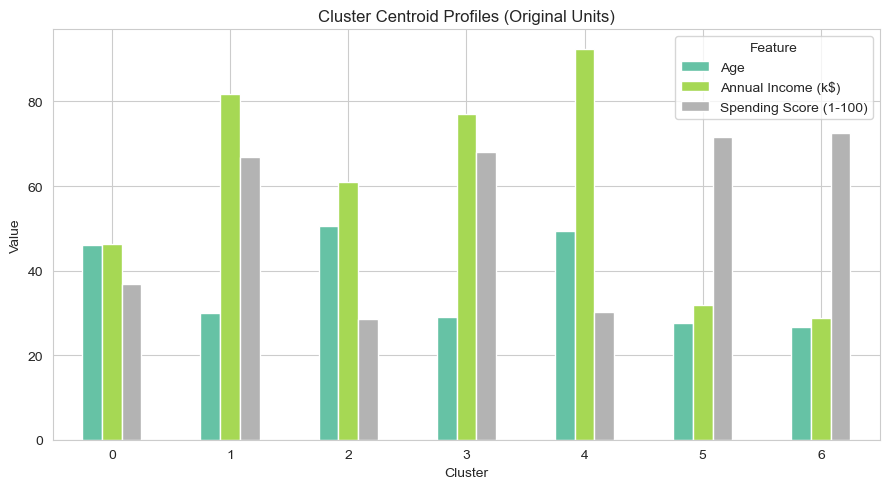

In [25]:
profile_cols = [c for c in [age_col, income_col, score_col] if c in centroids_df.columns]

centroids_df[profile_cols].plot(kind="bar", figsize=(9, 5), colormap="Set2")
plt.title("Cluster Centroid Profiles (Original Units)")
plt.xlabel("Cluster")
plt.ylabel("Value")
plt.xticks(rotation=0)
plt.legend(title="Feature")
plt.tight_layout()
plt.show()


## 13. Export Results

In [26]:
OUTPUT_PATH = "customer_segments_output.csv"
df.to_csv(OUTPUT_PATH, index=False)
print(f"Saved labeled dataset to {OUTPUT_PATH}")

PERSONA_PATH = "persona_matrix.csv"
persona_matrix.to_csv(PERSONA_PATH)
print(f"Saved persona matrix to {PERSONA_PATH}")


Saved labeled dataset to customer_segments_output.csv
Saved persona matrix to persona_matrix.csv


## 14. Summary

| Phase | Step | Technique |
|---|---|---|
| 1. Scale | Standardize features | `StandardScaler` |
| 2. Compress | Reduce dimensionality | `PCA` (95% variance rule) |
| 3. Cluster | Find optimal K, fit model | Elbow Method + Silhouette Score + `KMeans` |
| 4. Translate | Recover business meaning | Inverse PCA + inverse scaling → Persona Matrix |

This notebook mathematically justifies the chosen number of clusters (rather than guessing K), and turns abstract PCA-space centroids back into concrete, actionable customer personas your business stakeholders can use directly.
